In [36]:
from langgraph.graph import StateGraph,START,END
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from dotenv import load_dotenv
from typing import TypedDict,Annotated
from langgraph.checkpoint.memory import InMemorySaver


In [37]:
load_dotenv()

True

In [38]:
class Jokes(TypedDict):
    topic:str
    genjoke:str
    explainjoke:str

In [39]:
llm=HuggingFaceEndpoint(
     repo_id="Qwen/Qwen3-8B",
        task="text-generation",
       # max_new_tokens=512,
        temperature=0.7,
       # huggingfacehub_api_token=token,
)
model=ChatHuggingFace(llm=llm)

#result=model.invoke('capital of India ')
#print(result)

In [40]:
def Gen_Joke(state: Jokes):
    prompt = f"Generate a funny joke about {state['topic']}. Return ONLY the joke."
    response = model.invoke(prompt).content

    print("GENERATED JOKE:", repr(response))

    return {
        'genjoke': response
    }

In [41]:
def Explain_Joke(state: Jokes):
    print("JOKE RECEIVED BY EXPLAIN NODE:", repr(state['genjoke']))

    prompt = f"""
Explain the following joke clearly and briefly:

JOKE:
{state['genjoke']}
"""

    response = model.invoke(prompt).content

    return {
        'explainjoke': response
    }

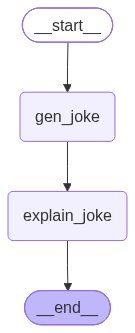

In [42]:
graph=StateGraph(Jokes)
graph.add_node('gen_joke',Gen_Joke)
graph.add_node('explain_joke',Explain_Joke)

graph.add_edge(START,'gen_joke')
graph.add_edge('gen_joke','explain_joke')
graph.add_edge('explain_joke',END)

checkpointer=InMemorySaver()
graph.compile()


In [43]:
workflow=graph.compile(checkpointer=checkpointer)
config={'configurable':{'thread_id':'1'}}
result=workflow.invoke({'topic':'pizza'},config=config)


GENERATED JOKE: ''
JOKE RECEIVED BY EXPLAIN NODE: ''


In [44]:
print(result['topic'])
print(result['genjoke'])
print(result['explainjoke'])

pizza



It seems the joke was not included in your message. Could you please share the joke you'd like me to explain? I'd be happy to help once I have the content! 😊
